In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.svm import SVC

In [2]:
df = pd.read_csv('cricket_data.csv')

In [3]:
df

,player_id,player_name,team,opponent,role,match_format,venue,match_date,pitch_type,weather,...,bowling_average,dot_ball_percentage,catches,run_outs,stumpings,form_score,fantasy_points,player_rating,player_form_label,selected_in_best_xi
0,P103,Maxwell,Australia,India,All-rounder,T20,Lords,2024-12-30,Bowling Friendly,Sunny,...,4.0,49.97,0,0,0,57.80,112,58.03,Average,1
1,P59,Mushfiq,West Indies,Australia,Wicketkeeper,T20,Mirpur Stadium,2022-05-26,Batting Friendly,Cloudy,...,0.0,0.00,0,1,0,32.81,40,36.85,Poor,0
2,P242,Rabada,India,West Indies,Bowler,ODI,Lords,2023-02-16,Balanced,Rainy,...,0.0,44.88,2,0,0,15.93,19,17.78,Poor,0
3,P446,Gill,England,New Zealand,All-rounder,ODI,MCG,2023-09-23,Bowling Friendly,Humid,...,0.0,25.47,1,0,0,22.57,42,22.33,Poor,0
4,P41,Babar,Australia,South Africa,All-rounder,ODI,Mirpur Stadium,2023-11-18,Balanced,Rainy,...,25.0,36.49,0,0,0,27.57,33,24.51,Poor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,P296,Hardik,Afghanistan,India,All-rounder,ODI,Dubai Stadium,2024-08-08,Batting Friendly,Cloudy,...,0.0,25.85,1,0,0,35.47,84,36.05,Poor,1
19996,P41,Starc,Sri Lanka,India,All-rounder,T20,The Oval,2021-12-05,Spin Friendly,Sunny,...,0.0,30.05,0,0,0,13.26,2,16.18,Poor,0
19997,P463,Rahim,Bangladesh,Pakistan,Wicketkeeper,T20,Wankhede Stadium,2023-06-30,Batting Friendly,Cloudy,...,0.0,0.00,0,0,0,51.55,64,42.53,Average,1
19998,P137,Rahim,England,Pakistan,All-rounder,ODI,The Oval,2022-11-01,Bowling Friendly,Cloudy,...,25.0,33.94,0,0,0,22.03,25,21.08,Poor,1


In [4]:
df.describe()

,opponent_strength,last_5_runs,last_5_wickets,last_5_avg,last_5_strike_rate,last_5_economy,runs_scored,balls_faced,fours,sixes,...,economy_rate,bowling_average,dot_ball_percentage,catches,run_outs,stumpings,form_score,fantasy_points,player_rating,selected_in_best_xi
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,67.754379,129.724600,3.060150,25.944920,117.308741,3.889098,25.318500,40.595150,1.402000,0.891550,...,3.892645,7.366736,19.978722,0.46630,0.140950,0.087500,32.894277,49.398250,32.562585,0.488650
std,15.904548,105.058392,4.334394,21.011678,187.368868,4.172929,20.184577,35.103401,1.629947,1.184677,...,4.042281,14.903585,20.964947,0.72401,0.376019,0.327336,15.751162,30.415223,12.763239,0.499884
min,40.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,5.000000,0.000000,4.320000,0.000000
25%,54.090000,41.000000,0.000000,8.200000,24.280000,0.000000,9.000000,14.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,20.820000,27.000000,23.050000,0.000000
50%,67.845000,113.000000,1.000000,22.600000,65.735000,0.000000,22.000000,29.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,31.320000,46.000000,31.460000,0.000000
75%,81.582500,200.000000,5.000000,40.000000,139.205000,7.780000,39.000000,55.000000,2.000000,1.000000,...,7.780000,9.000000,40.272500,1.00000,0.000000,0.000000,43.390000,68.000000,40.860000,1.000000
max,95.000000,689.000000,25.000000,137.800000,3798.290000,14.710000,127.000000,150.000000,15.000000,9.000000,...,10.480000,102.000000,55.000000,3.00000,2.000000,2.000000,100.000000,199.000000,91.450000,1.000000


In [5]:
df.shape

(20000, 37)

In [6]:
df.isnull().sum()

player_id              0
player_name            0
team                   0
opponent               0
role                   0
match_format           0
venue                  0
match_date             0
pitch_type             0
weather                0
home_away              0
match_importance       0
opponent_strength      0
last_5_runs            0
last_5_wickets         0
last_5_avg             0
last_5_strike_rate     0
last_5_economy         0
runs_scored            0
balls_faced            0
fours                  0
sixes                  0
strike_rate            0
overs_bowled           0
runs_conceded          0
wickets_taken          0
economy_rate           0
bowling_average        0
dot_ball_percentage    0
catches                0
run_outs               0
stumpings              0
form_score             0
fantasy_points         0
player_rating          0
player_form_label      0
selected_in_best_xi    0
dtype: int64

In [7]:
df = df.drop(columns=['player_id','player_name','match_date','fantasy_points','player_rating','selected_in_best_xi'])

In [8]:
df.dtypes

team                    object
opponent                object
role                    object
match_format            object
venue                   object
pitch_type              object
weather                 object
home_away               object
match_importance        object
opponent_strength      float64
last_5_runs              int64
last_5_wickets           int64
last_5_avg             float64
last_5_strike_rate     float64
last_5_economy         float64
runs_scored              int64
balls_faced              int64
fours                    int64
sixes                    int64
strike_rate            float64
overs_bowled           float64
runs_conceded            int64
wickets_taken            int64
economy_rate           float64
bowling_average        float64
dot_ball_percentage    float64
catches                  int64
run_outs                 int64
stumpings                int64
form_score             float64
player_form_label       object
dtype: object

In [9]:
le = LabelEncoder()
y = le.fit_transform(df['player_form_label'])
X = df.drop(columns=['player_form_label'])


In [10]:
nominal_cols = ['team','opponent','role','match_format',
                'venue','pitch_type','weather','home_away']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True, dtype=int)


In [11]:
print(X['match_importance'].unique())
X['match_importance'] = X['match_importance'].map({'Low': 0, 'Medium': 1, 'High': 2})


['High' 'Low' 'Medium']


In [12]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

In [13]:
scalar = MinMaxScaler()
X_train_scale = scalar.fit_transform(X_train)
X_test_scale = scalar.transform(X_test)

In [14]:
model = SVC(kernel='rbf',C = 1.0,random_state=42, probability=True)
model.fit(X_train_scale,y_train)

SVC(probability=True, random_state=42)

In [15]:
y_pred = model.predict(X_test_scale)

In [16]:
y_pred_proba = model.predict_proba(X_test_scale)

In [17]:
print("Confusion Matrix is :", confusion_matrix(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("Classification Report",classification_report(y_test,y_pred))

Confusion Matrix is : [[ 911    0    8  111]
 [   0    0   16    0]
 [  93    0  125    0]
 [  62    0    0 2674]]
accuracy_score: 0.9275
Classification Report               precision    recall  f1-score   support

           0       0.85      0.88      0.87      1030
           1       0.00      0.00      0.00        16
           2       0.84      0.57      0.68       218
           3       0.96      0.98      0.97      2736

    accuracy                           0.93      4000
   macro avg       0.66      0.61      0.63      4000
weighted avg       0.92      0.93      0.92      4000



c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

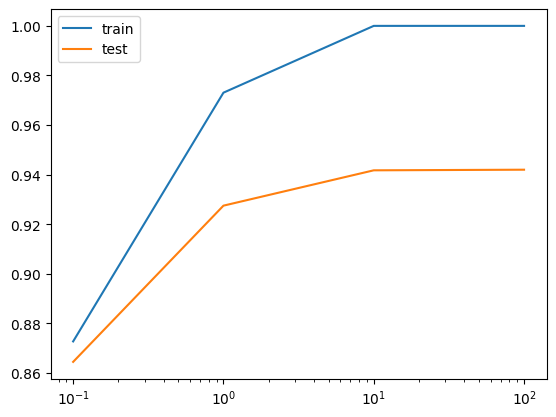

In [18]:
import matplotlib.pyplot as plt
train_score , test_score = [] ,[]
c_values = [0.1,1,10,100]

for c in c_values:
    m = SVC(kernel='rbf',C = c   ,random_state= 42)
    m.fit(X_train_scale,y_train)
    train_score.append(m.score(X_train_scale,y_train))
    test_score.append(m.score(X_test_scale,y_test))

plt.plot(c_values,train_score,label = "train")
plt.plot(c_values,test_score,label = "test")
plt.xscale('log')
plt.legend()
plt.show()

In [19]:
best_n = np.argmax(test_score)
best_c = c_values[best_n]
print("bets c",best_c)

model = SVC(kernel='rbf',C = best_c , random_state= 42 )
model.fit(X_train_scale,y_train)

bets c 100


SVC(C=100, random_state=42)

In [20]:
y_pred = model.predict(X_test_scale)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Train Score:", model.score(X_train_scale, y_train))
print("Test Score:", model.score(X_test_scale, y_test))

[[ 925    0   23   82]
 [   0    6   10    0]
 [  50    0  168    0]
 [  67    0    0 2669]]
0.942
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      1030
           1       1.00      0.38      0.55        16
           2       0.84      0.77      0.80       218
           3       0.97      0.98      0.97      2736

    accuracy                           0.94      4000
   macro avg       0.92      0.75      0.80      4000
weighted avg       0.94      0.94      0.94      4000

Train Score: 1.0
Test Score: 0.942
